# **Model 7 Parameters:**
## **Inputs:** 
* SMILES strings of chemical structures and experimental DMSO-normalized ZBTB11 and IKZF1 abundance values at 10 test MGD concentrations (%), ipTM scores from RoseTTAFold 3 modeling, minimized energy of the complex from OpenFF/OpenMM, ratio of successful CRBN:MGD:substrate complexes
## **Outputs:** 
* Predicted ZBTB11 and IKZF1 abundance values at each MGD concentration (%)
## **Approach:** 
* Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning and Hybrid MSE Curve Fitting + Contrastive Learning Loss Function
* Split single FFN into two separate ZBTB11- and IKZF1-specialized FFNs, introduced target weight to prioritize target-specific MSE loss
## **Baseline:** 
* Ridge Regression on Morgan fingerprints and features calculated from 3D modeling/minimization
## **Data Splitting** 
* Data split according to computed Bemis-Murcko scaffolds using astartes package, keeping similar scaffolds in same set
* 80/10/10% train/validation/test

### **Package Installs and Imports**

In [1]:
!pip install optuna optuna-integration lightning chemprop ipywidgets umap-learn matplotlib seaborn pytorch-metric-learning

In [2]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [3]:
# General Use
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from IPython.display import Image, display

# Standard Machine Learning & Viz
import umap
import optuna
from optuna.integration import PyTorchLightningPruningCallback
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

# Deep Learning Frameworks
import gc
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from lightning import pytorch as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

# Chemprop (V2)
from chemprop import data, featurizers, models, nn
from chemprop.models import MPNN

# Custom Loss
from pytorch_metric_learning.losses import NTXentLoss

### **Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [4]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

### **Data Splitting, Loading, and Inspection**

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)



--- SupCon Class Distribution ---
SupCon_Class
0    35
2    42
3    11
Name: count, dtype: int64
Unified data preparation complete with injected 3D features!


/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/astartes/main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.80, got 0.82. Requested validation size of 0.10, got 0.09. Requested test size of 0.10, got 0.09. 
  warn(
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use MorganGenerator
[17:54:21] DEPRECATION WARNING: please use Morg

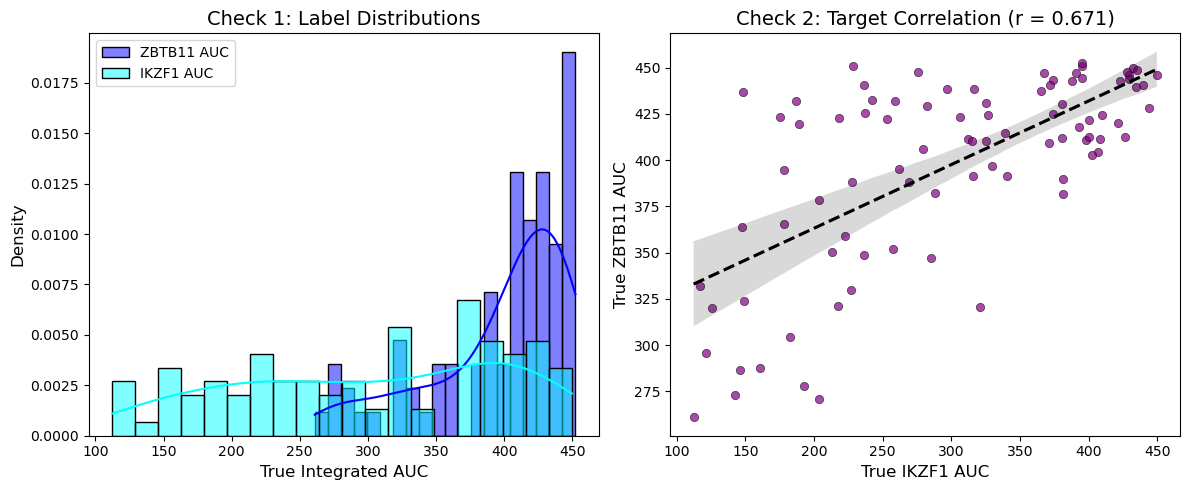


Pearson Correlation between targets in whole dataset: 0.671 (p-value: 8.67e-13)
-> High correlation detected! Optimizing for IKZF1 inherently optimizes for ZBTB11.


In [5]:
def assign_supcon_classes(df, z_auc_col, i_auc_col, active_max_auc, selectivity_margin):
    z_auc = df[z_auc_col]
    i_auc = df[i_auc_col]
    
    cond_inactive = (z_auc > active_max_auc) & (i_auc > active_max_auc)
    cond_z_selective = (z_auc <= active_max_auc) & ((i_auc > active_max_auc) | ((i_auc - z_auc) >= selectivity_margin))
    cond_i_selective = (i_auc <= active_max_auc) & ((z_auc > active_max_auc) | ((z_auc - i_auc) >= selectivity_margin))
    cond_dual = (z_auc <= active_max_auc) & (i_auc <= active_max_auc) & (abs(z_auc - i_auc) < selectivity_margin)
    
    choices = [0, 1, 2, 3]
    df['SupCon_Class'] = np.select([cond_inactive, cond_z_selective, cond_i_selective, cond_dual], choices, default=0)
    
    print("\n--- SupCon Class Distribution ---")
    print(df['SupCon_Class'].value_counts().sort_index())
    return df

def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)))
        else:
            fps.append(np.zeros((n_bits,)))
    return np.array(fps)

def clean_assay_data(df, target_cols):
    df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
    df[target_cols] = df[target_cols].clip(lower=0, upper=100)              
    return df.dropna(subset=target_cols, how='all')                         


# 1. LOAD FULL DATASET & MERGE BOTH ZBTB11 AND IKZF1 3D FEATURES
df = pd.read_csv("zbtb11_mgd_input.csv")

rf3_df_zbtb = pd.read_csv("rf3_features_with_thermodynamics_zbtb11.csv")
rf3_df_ikzf = pd.read_csv("rf3_features_with_thermodynamics_ikzf1.csv")

rf3_subset_zbtb = rf3_df_zbtb[[
    'SMILES', 
    'ipTM_zbtb11', 
    'Fraction_Success_Under_10A_zbtb11', 
    'OpenMM_Minimized_Energy_kJ_mol_zbtb11'
]].groupby('SMILES').mean().reset_index()

rf3_subset_ikzf = rf3_df_ikzf[[
    'SMILES', 
    'ipTM_ikzf1', 
    'Fraction_Success_Under_10A_ikzf1', 
    'OpenMM_Minimized_Energy_kJ_mol_ikzf1'
]].groupby('SMILES').mean().reset_index()

rf3_combined = pd.merge(rf3_subset_zbtb, rf3_subset_ikzf, on='SMILES', how='inner')

df = df.merge(rf3_combined, on='SMILES', how='inner')

df['OpenMM_Minimized_Energy_kJ_mol_zbtb11'] = df['OpenMM_Minimized_Energy_kJ_mol_zbtb11'].fillna(0)
df['OpenMM_Minimized_Energy_kJ_mol_ikzf1'] = df['OpenMM_Minimized_Energy_kJ_mol_ikzf1'].fillna(0)

robust_scaler_zbtb = RobustScaler()
df['Scaled_Energy_zbtb11'] = robust_scaler_zbtb.fit_transform(df[['OpenMM_Minimized_Energy_kJ_mol_zbtb11']])

robust_scaler_ikzf = RobustScaler()
df['Scaled_Energy_ikzf1'] = robust_scaler_ikzf.fit_transform(df[['OpenMM_Minimized_Energy_kJ_mol_ikzf1']])

extra_feature_cols = [
    'ipTM_zbtb11', 
    'Fraction_Success_Under_10A_zbtb11', 
    'Scaled_Energy_zbtb11',
    'ipTM_ikzf1', 
    'Fraction_Success_Under_10A_ikzf1', 
    'Scaled_Energy_ikzf1'
]

concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
targets = [f'zbtb11_{c}' for c in concs] + [f'ikzf1_{c}' for c in concs]

df = clean_assay_data(df, targets)

conc_nM = [3, 10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000]
log_conc = np.log10(conc_nM)

zbtb11_cols = [f'zbtb11_{c}' for c in concs]
ikzf1_cols = [f'ikzf1_{c}' for c in concs]

df['True_ZBTB11_AUC'] = df[zbtb11_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)
df['True_IKZF1_AUC'] = df[ikzf1_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)

df['True_IKZF1_AUC'] = df['True_IKZF1_AUC'].fillna(df['True_ZBTB11_AUC'])

df = assign_supcon_classes(df, 'True_ZBTB11_AUC', 'True_IKZF1_AUC', active_max_auc=360.0, selectivity_margin=135.0)
df.to_csv("zbtb11_mgd_auc_labels_input.csv", index=False)

smiles_list = df['SMILES'].tolist()
y_values = df[targets + ['SupCon_Class']].values

x_d_values = df[extra_feature_cols].values


# 2. CREATE CHEM PROP DATAPOINTS & GENERATE SCAFFOLD SPLIT
all_datapoints = [
    data.MoleculeDatapoint.from_smi(smi=smi, y=y, x_d=x) 
    for smi, y, x in zip(smiles_list, y_values, x_d_values)
]

all_mols = [d.mol for d in all_datapoints]
train_idx, val_idx, test_idx = data.make_split_indices(
    all_mols,
    split="scaffold_balanced", 
    sizes=(0.8, 0.10, 0.10), 
    seed=42
)


# 3. APPLY INDICES TO CHEM PROP (DEEP LEARNING PREP)
train_data, val_data, test_data = data.split_data_by_indices(
    all_datapoints, train_idx, val_idx, test_idx
)

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_data[0], featurizer)
val_dset = data.MoleculeDataset(val_data[0], featurizer)
test_dset = data.MoleculeDataset(test_data[0], featurizer)

raw_supcon_labels = [dp.y[-1] for dp in train_data[0]]

output_scaler = train_dset.normalize_targets()

for i, dp in enumerate(train_data[0]):
    dp.y[-1] = raw_supcon_labels[i]

if output_scaler is not None:
    try:
        output_scaler.means[-1] = 0.0
        output_scaler.stds[-1] = 1.0
    except AttributeError:
        output_scaler.mean_[-1] = 0.0
        output_scaler.scale_[-1] = 1.0

val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)

train_loader = DataLoader(
    train_dset,             
    batch_size=32,         
    shuffle=True,            
    collate_fn=data.collate_batch, 
    drop_last=True          
)

val_loader = DataLoader(
    val_dset,                
    batch_size=32,         
    shuffle=False,          
    collate_fn=data.collate_batch,   
    drop_last=False         
)

test_loader = DataLoader(
    test_dset,              
    batch_size=32,
    shuffle=False,
    collate_fn=data.collate_batch,  
    drop_last=False
)


# 4. APPLY INDICES TO PANDAS/SCIKIT-LEARN (CLASSICAL ML PREP)
train_idx_flat = np.array(train_idx).flatten()
test_idx_flat = np.array(test_idx).flatten()

train_df = df.iloc[train_idx_flat].copy()
test_df = df.iloc[test_idx_flat].copy()

X_train_morgan = smiles_to_morgan(train_df['SMILES'].tolist())
X_test_morgan = smiles_to_morgan(test_df['SMILES'].tolist())

X_train_extra = train_df[extra_feature_cols].values
X_test_extra = test_df[extra_feature_cols].values

X_train_combined = np.hstack([X_train_morgan, X_train_extra])
X_test_combined = np.hstack([X_test_morgan, X_test_extra])

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_combined)
X_test_scaled = scaler_X.transform(X_test_combined)

print("Unified data preparation complete with injected 3D features!")


# 5. DATASET BEHAVIOR CHECKS (TARGET CORRELATION & DATA DISTRIBUTION)
clean_df = df.dropna(subset=['True_ZBTB11_AUC', 'True_IKZF1_AUC'])

# --- CHECK 1: Distributions ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(clean_df['True_ZBTB11_AUC'], color='blue', label='ZBTB11 AUC', kde=True, stat="density", bins=20, alpha=0.5)
sns.histplot(clean_df['True_IKZF1_AUC'], color='cyan', label='IKZF1 AUC', kde=True, stat="density", bins=20, alpha=0.5)
plt.title("Check 1: Label Distributions", fontsize=14)
plt.xlabel("True Integrated AUC", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()

# --- CHECK 2: Correlation ---
plt.subplot(1, 2, 2)
sns.scatterplot(data=clean_df, x='True_IKZF1_AUC', y='True_ZBTB11_AUC', alpha=0.7, color='purple', edgecolor='k')

r_val, p_val = pearsonr(clean_df['True_IKZF1_AUC'], clean_df['True_ZBTB11_AUC'])

sns.regplot(data=clean_df, x='True_IKZF1_AUC', y='True_ZBTB11_AUC', scatter=False, color='black', line_kws={"linestyle": "--"})

plt.title(f"Check 2: Target Correlation (r = {r_val:.3f})", fontsize=14)
plt.xlabel("True IKZF1 AUC", fontsize=12)
plt.ylabel("True ZBTB11 AUC", fontsize=12)

plt.tight_layout()
plt.savefig("data_checks.png", dpi=300)
plt.show()

print(f"\nPearson Correlation between targets in whole dataset: {r_val:.3f} (p-value: {p_val:.2e})")
if r_val > 0.6:
    print("-> High correlation detected! Optimizing for IKZF1 inherently optimizes for ZBTB11.")
else:
    print("-> Low correlation. The targets are distinct, pointing more toward differences in distribution complexity.")

### **Baseline Ridge Regression Model Training and Evaluation**


--- Top Predicted Selective Compounds ---
      Molecule                                             SMILES  \
73  JWJ-01-563  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...   
69  JWJ-01-557  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...   
77  JWJ-01-571  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...   
46  JWJ-01-323  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...   
45  JWJ-01-322  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...   

    Pred_ZBTB11_Selectivity  True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  \
73               -36.701835              -222.320777       433.596171   
69               -55.820338              -288.607287       429.923463   
77              -104.540166              -141.692576       417.320448   
46              -106.967969                 1.011474       419.274752   
45              -113.294746                 2.552514       398.459061   

    True_ZBTB11_AUC  
73       450.723594  
69       436.649134  
77       438.465436  
46       420.34

/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


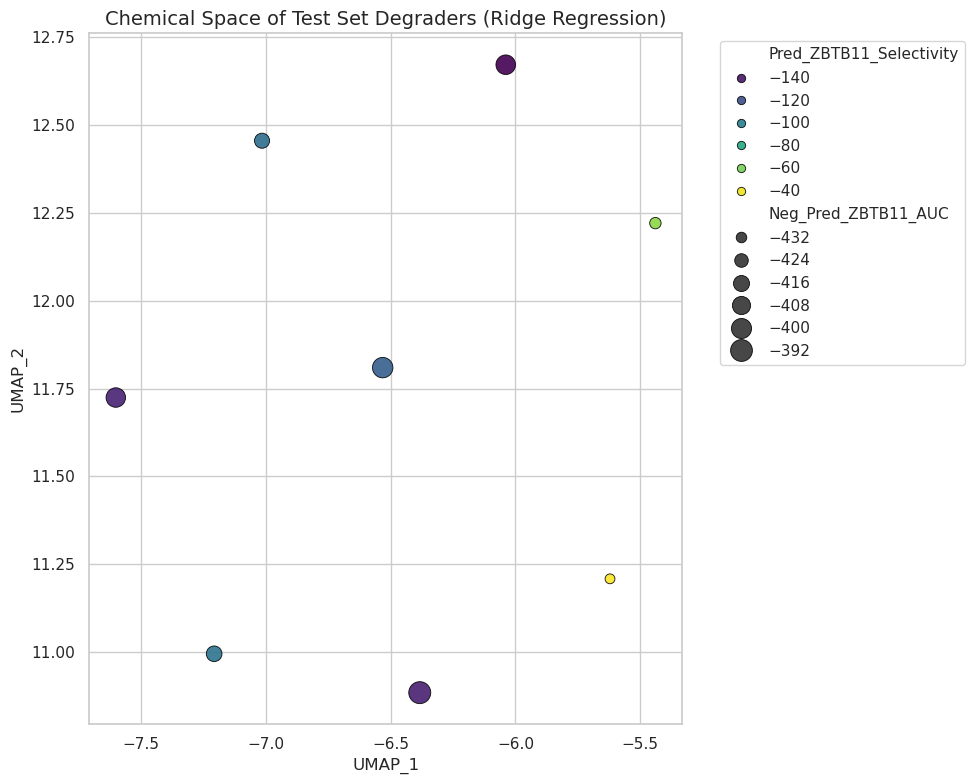


Overall Average Across All Concentrations -> RMSE: 17.601 | R²: -5.224

--- Baseline Regression Metrics (Per Concentration) ---
    Endpoint  N_Valid   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM        8  1.207  1.028   0.120      0.516
 zbtb11_10nM        8  1.905  1.785  -0.697     -0.050
 zbtb11_30nM        8  3.300  3.179 -15.975      0.503
zbtb11_100nM        8  4.936  4.689  -3.510      0.770
zbtb11_300nM        8  7.338  7.244 -27.762      0.758
  zbtb11_1uM        8  9.907  9.449 -42.698     -0.261
  zbtb11_3uM        8  8.313  7.974  -5.609      0.700
 zbtb11_10uM        8  4.553  4.091  -0.053      0.714
 zbtb11_30uM        8  9.887  8.538   0.546      0.848
zbtb11_100uM        8 22.516 18.198   0.329      0.866
   ikzf1_3nM        8  6.728  4.338  -0.168     -0.272
  ikzf1_10nM        8 14.183 11.019  -0.135     -0.312
  ikzf1_30nM        8 27.502 22.487  -0.595     -0.581
 ikzf1_100nM        8 32.199 27.037  -0.714     -0.536
 ikzf1_300nM        8 34.340 29.971  -0.863   

In [6]:
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)


# 1. TRAIN 20 INDEPENDENT RIDGE MODELS
trained_models = {}
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

for target in targets:
    y_train = train_df[target].values
    valid_mask = ~np.isnan(y_train)
    
    if valid_mask.sum() > 5:
        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_train_scaled[valid_mask], y_train[valid_mask])
        trained_models[target] = model
    else:
        print(f"Warning: Not enough data for {target}. Skipping.")


# 2. PREDICT AND CALCULATE TRUE AREA UNDER CURVE (AUC)

true_target_cols = list(trained_models.keys())
test_results_df = test_df[['Molecule', 'SMILES'] + true_target_cols].copy()

for target in trained_models.keys():
    test_results_df[f'Pred_{target}'] = trained_models[target].predict(X_test_scaled)

pred_zbtb11_cols = [f'Pred_zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
pred_ikzf1_cols = [f'Pred_ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

zbtb11_x = [log_conc[i] for i, c in enumerate(concs) if f'zbtb11_{c}' in trained_models]
ikzf1_x = [log_conc[i] for i, c in enumerate(concs) if f'ikzf1_{c}' in trained_models]

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_ridge_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds ---")
print(test_results_df[['Molecule', 'SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 3. UMAP PLOTTING
test_results_df = test_results_df.sort_index()

reducer = umap.UMAP(n_neighbors=min(5, len(X_test_scaled) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(X_test_scaled)

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders (Ridge Regression)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ridge_umap.png", dpi=600, bbox_inches='tight')
plt.show()


# 4. EVALUATE REGRESSION METRICS
evaluation_results = []
valid_targets = list(trained_models.keys())

for true_col in valid_targets:
    pred_col = f'Pred_{true_col}'
    
    y_true = test_df.loc[test_results_df.index, true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid': len(y_true_valid),
        'RMSE': round(rmse, 3), 
        'MAE': round(mae, 3),
        'R²': round(r2, 3), 
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_ridge_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Baseline Regression Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

### **Chemprop Model Training and Evaluation**

/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/chemprop/nn/transforms.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.cat([torch.zeros(pad), torch.tensor(mean, dtype=torch.float)])
/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/chemprop/nn/transforms.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.cat([torch.ones(pad), torch.tensor(scale, dtype=torch.float)])
[I 2026-03-17 17:54:27,974] A new study created in memory with name: no-name-a94d1020-e623-4904-974e-ff5ff16aa92d
/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'message_passing

┏━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ message_passing │ BondMessagePassing │  579 K │ train │     0 │
│ 1  │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2  │ bn              │ Identity           │      0 │ train │     0 │
│ 3  │ predictor       │ RegressionFFN      │  252 K │ train │     0 │
│ 4  │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5  │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6  │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7  │ z_norm          │ LayerNorm          │  1.0 K │ train │     0 │
│ 8  │ i_norm          │ LayerNorm          │  1.0 K │ train │     0 │
│ 9  │ all_norm        │ LayerNorm          │  1.0 K │ train │     0 │
│ 10 │ zbtb11_ffn      │ RegressionFFN      │  758 K │ train │     0 │
│ 11 │ ikzf1_ffn       │ RegressionFFN      │  758 K │ train │     0 │
│ 12 │ projection_head │ Sequential         │  285 K │ train │     0 │
└────┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 62                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 293. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1211. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Tryin

--- Trial 0 EARLY STOPPED at epoch 84 (Best val_mean_rmse: 0.9810) ---


...

┏━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ message_passing │ BondMessagePassing │  815 K │ train │     0 │
│ 1  │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2  │ bn              │ Identity           │      0 │ train │     0 │
│ 3  │ predictor       │ RegressionFFN      │  363 K │ train │     0 │
│ 4  │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5  │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6  │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7  │ z_norm          │ LayerNorm          │  1.2 K │ train │     0 │
│ 8  │ i_norm          │ LayerNorm          │  1.2 K │ train │     0 │
│ 9  │ all_norm        │ LayerNorm          │  1.2 K │ train │     0 │
│ 10 │ zbtb11_ffn      │ RegressionFFN      │  729 K │ train │     0 │
│ 11 │ ikzf1_ffn       │ RegressionFFN      │  729 K │ train │     0 │
│ 12 │ projection_head │ Sequential         │  402 K │ train │     0 │
└────┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 3.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.0 M                                                                                                
Total estimated model params size (MB): 12                                                                         
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_mean_rmse improved. New best score: 1.082
Metric val_mean_rmse improved by 0.001 >= min_delta = 0.0. New best score: 1.081
Metric val_mean_rmse improved by 0.051 >= min_delta = 0.0. New best score: 1.030
Metric val_mean_rmse improved by 0.009 >= min_delta = 0.0. New best score: 1.020
Metric val_mean_rmse improved by 0.002 >= min_delta = 0.0. New best score: 1.018
Metric val_mean_rmse improved by 0.096 >= min_delta = 0.0. New best score: 0.922
Monitored metric val_mean_rmse did not improve in the last 50 records. Best score: 0.922. Signaling Trainer to stop.
Trainer was signaled to stop but the required `min_epochs=150` or `min_steps=None` has not been met. Training will continue...
Monitored metric val_mean_rmse did not improve in the last 51 records. Best score: 0.922. Signaling Trainer to stop.
Monitored metric val_mean_rmse did not improve in the last 52 records. Best score: 0.922. Signaling Trainer to stop.
Monitored metric val_mean_rmse did not improve in the last 53 re


Restoring best weights from: training_logs/chemprop_model/version_16/checkpoints/best_model-epoch=68-val_mean_rmse=0.9222.ckpt


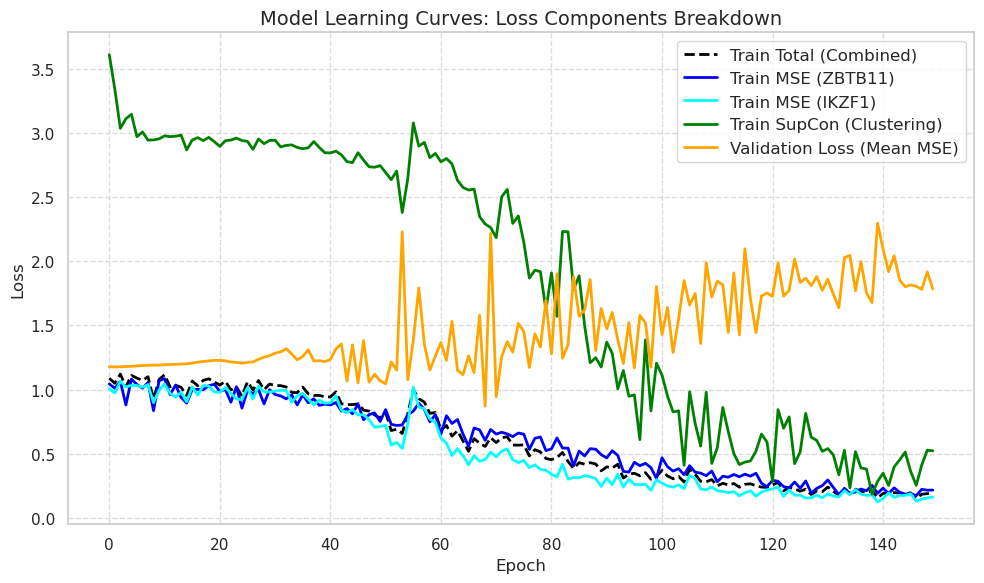

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


/home/ntran/miniconda3/envs/physics_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---
     Molecule                                             SMILES  \
4  JWJ-01-323  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...   
7  JWJ-01-563  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...   
3  JWJ-01-322  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...   
0  JWJ-01-571  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...   
6  JWJ-01-557  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...   

   Pred_ZBTB11_Selectivity  True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  \
4               -32.208909                 1.011474       396.460730   
7               -47.535521              -222.320777       446.366937   
3               -57.606248                 2.552514       393.106916   
0               -72.515463              -141.692576       429.321393   
6               -79.676688              -288.607287       426.919837   

   True_ZBTB11_AUC  
4       420.347358  
7       450.723594  
3       404.4

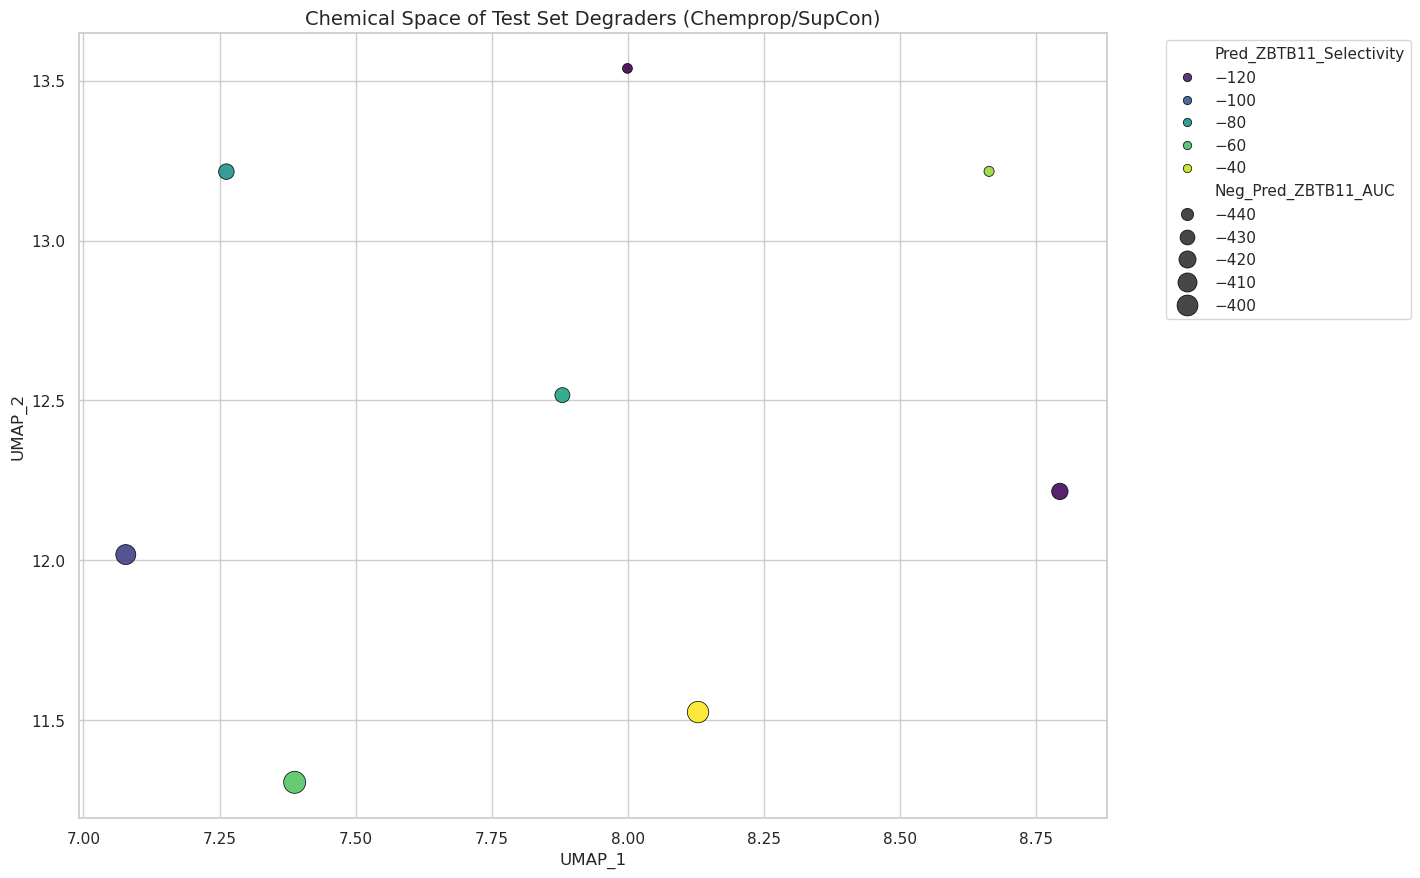


Overall Average Across All Concentrations -> RMSE: 15.559 | R²: -2.656

--- Regression Evaluation Metrics (Per Concentration) ---
    Endpoint  N_Valid_Points   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM               8  1.449  0.943  -0.270     -0.310
 zbtb11_10nM               8  1.366  1.083   0.128      0.605
 zbtb11_30nM               8  2.092  1.851  -5.822      0.163
zbtb11_100nM               8  5.478  4.303  -4.555     -0.617
zbtb11_300nM               8  4.942  4.230 -12.047     -0.100
  zbtb11_1uM               8  7.109  5.612 -21.502     -0.056
  zbtb11_3uM               8  6.221  4.873  -2.700      0.324
 zbtb11_10uM               8  8.021  5.883  -2.267      0.302
 zbtb11_30uM               8  9.236  6.445   0.604      0.861
zbtb11_100uM               8 23.810 19.133   0.250      0.907
   ikzf1_3nM               8  6.707  3.795  -0.161      0.318
  ikzf1_10nM               8 14.931  9.139  -0.257      0.022
  ikzf1_30nM               8 23.386 15.697  -0.154     -0.026
 

In [7]:
# 1. Custom Supervised Contrastive Learning Model Wrapper (Branched Y-Network)
class BranchedSupConMPNN(MPNN):
    def __init__(self, message_passing, agg, d_h, n_layers, dropout, out_transform_z, out_transform_i, supcon_weight, target_weight, temperature, lr=1e-3, extra_features_dim=6):
        zbtb11_features_dim = 3
        ikzf1_features_dim = 3
        
        dummy_input_dim = message_passing.output_dim + zbtb11_features_dim
        dummy_ffn = nn.RegressionFFN(n_tasks=1, input_dim=dummy_input_dim, hidden_dim=d_h, n_layers=1)
        super().__init__(message_passing, agg, dummy_ffn)
        
        self.ntxent_loss = NTXentLoss(temperature=temperature)
        self.supcon_weight = supcon_weight
        self.target_weight = target_weight
        self.lr = lr 
        
        self.register_buffer("mean_z", out_transform_z.mean.clone().detach().squeeze())
        self.register_buffer("scale_z", out_transform_z.scale.clone().detach().squeeze())
        self.register_buffer("mean_i", out_transform_i.mean.clone().detach().squeeze())
        self.register_buffer("scale_i", out_transform_i.scale.clone().detach().squeeze())
        
        self.z_norm = torch_nn.LayerNorm(message_passing.output_dim + zbtb11_features_dim)
        self.i_norm = torch_nn.LayerNorm(message_passing.output_dim + ikzf1_features_dim)
        self.all_norm = torch_nn.LayerNorm(message_passing.output_dim + extra_features_dim)
        
        self.zbtb11_ffn = nn.RegressionFFN(
            n_tasks=10,
            input_dim=message_passing.output_dim + zbtb11_features_dim, 
            hidden_dim=d_h,
            n_layers=n_layers,
            dropout=dropout
        )
        
        self.ikzf1_ffn = nn.RegressionFFN(
            n_tasks=10,
            input_dim=message_passing.output_dim + ikzf1_features_dim,
            hidden_dim=d_h,
            n_layers=n_layers,
            dropout=dropout
        )
        
        self.projection_head = torch_nn.Sequential(
            torch_nn.Linear(message_passing.output_dim + extra_features_dim, d_h),
            torch_nn.ReLU(),
            torch_nn.Linear(d_h, 64)
        )

    def _hide_supcon_labels(self, batch): 
        new_Y = batch.Y[:, :20]
        new_w = batch.w[:, :20] if batch.w is not None and batch.w.dim() == 2 and batch.w.shape[1] > 20 else batch.w
        new_lt = batch.lt_mask[:, :20] if batch.lt_mask is not None and batch.lt_mask.dim() == 2 and batch.lt_mask.shape[1] > 20 else batch.lt_mask
        new_gt = batch.gt_mask[:, :20] if batch.gt_mask is not None and batch.gt_mask.dim() == 2 and batch.gt_mask.shape[1] > 20 else batch.gt_mask
        
        return batch._replace(Y=new_Y, w=new_w, lt_mask=new_lt, gt_mask=new_gt)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, 
            max_lr=self.lr,
            total_steps=self.trainer.estimated_stepping_batches,
            pct_start=0.3,
            anneal_strategy='cos'
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step"
            }
        }

    def _get_predictions(self, batch):
        H_v = self.message_passing(batch.bmg, batch.V_d)
        raw_fingerprints = self.agg(H_v, batch.bmg.batch)
        
        if batch.X_d is not None:
            zbtb11_3d_features = batch.X_d[:, :3]
            ikzf1_3d_features = batch.X_d[:, 3:]
            
            combined_z = torch.cat([raw_fingerprints, zbtb11_3d_features], dim=1)
            combined_i = torch.cat([raw_fingerprints, ikzf1_3d_features], dim=1)
            combined_all = torch.cat([raw_fingerprints, batch.X_d], dim=1)
            
            combined_z = self.z_norm(combined_z)
            combined_i = self.i_norm(combined_i)
            combined_all = self.all_norm(combined_all)
            
        else:
            combined_z = raw_fingerprints
            combined_i = raw_fingerprints
            combined_all = raw_fingerprints
            
        preds_z = self.zbtb11_ffn(combined_z)
        preds_i = self.ikzf1_ffn(combined_i)
        
        if preds_z.dim() == 3:
            preds_z = preds_z.squeeze(0)
        if preds_i.dim() == 3:
            preds_i = preds_i.squeeze(0)
            
        preds = torch.cat([preds_z, preds_i], dim=1)
        
        return preds, combined_all 

    def _compute_scaled_loss(self, preds, targets):
        preds_z = preds[:, :10]
        preds_i = preds[:, 10:20]
        targets_z = targets[:, :10]
        targets_i = targets[:, 10:20]
        
        mask_z = ~torch.isnan(targets_z)
        mask_i = ~torch.isnan(targets_i)
        
        mse_z = F.mse_loss(preds_z[mask_z], targets_z[mask_z]) if mask_z.any() else torch.tensor(0.0, device=preds.device)
        mse_i = F.mse_loss(preds_i[mask_i], targets_i[mask_i]) if mask_i.any() else torch.tensor(0.0, device=preds.device)
        
        return mse_z, mse_i

    def training_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, combined_all = self._get_predictions(mod_batch)
        
        mse_z, mse_i = self._compute_scaled_loss(preds, mod_batch.Y)
        
        blended_mse_loss = (self.target_weight * mse_z) + ((1.0 - self.target_weight) * mse_i)    # target_weight of 0.2 means 20% ZBTB11, 80% IKZF1
        
        raw_projections = self.projection_head(combined_all)
        projected_fps = F.normalize(raw_projections, p=2, dim=1)
        
        supcon_labels = batch.Y[:, 20]
        supcon_loss = self.ntxent_loss(projected_fps, supcon_labels) 
        
        total_loss = blended_mse_loss + (self.supcon_weight * supcon_loss)
        
        self.log("train_mse_z", mse_z, on_step=False, on_epoch=True, prog_bar=False)
        self.log("train_mse_i", mse_i, on_step=False, on_epoch=True, prog_bar=False)
        self.log("train_supcon_loss", supcon_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        
        return total_loss

    def validation_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        mse_z, mse_i = self._compute_scaled_loss(preds, mod_batch.Y)
        
        rmse_z = torch.sqrt(mse_z)
        rmse_i = torch.sqrt(mse_i)
        
        val_mean_rmse = (rmse_z + rmse_i) / 2.0
        
        val_loss = (mse_z + mse_i) / 2.0 
        
        self.log("val_loss", val_loss, on_step=False, on_epoch=True, prog_bar=False)
        self.log("val_mean_rmse", val_mean_rmse, on_step=False, on_epoch=True, prog_bar=True)
        
        return val_loss

    def test_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        mse_z, mse_i = self._compute_scaled_loss(preds, mod_batch.Y)
        
        rmse_z = torch.sqrt(mse_z)
        rmse_i = torch.sqrt(mse_i)
        test_mean_rmse = (rmse_z + rmse_i) / 2.0
        
        self.log("test_mean_rmse", test_mean_rmse, on_step=False, on_epoch=True, prog_bar=True)
        return test_mean_rmse

    def predict_step(self, batch, *args, **kwargs):
        mod_batch = self._hide_supcon_labels(batch)
        preds, _ = self._get_predictions(mod_batch)
        
        preds_z_unscaled = (preds[:, :10] * self.scale_z) + self.mean_z
        preds_i_unscaled = (preds[:, 10:20] * self.scale_i) + self.mean_i
        
        return torch.cat([preds_z_unscaled, preds_i_unscaled], dim=1)


# 2. HYPERPARAMETER TUNING WITH OPTUNA
full_transform = nn.UnscaleTransform.from_standard_scaler(output_scaler)

sliced_mean_zbtb = full_transform.mean[..., :10]
sliced_scale_zbtb = full_transform.scale[..., :10]
out_transform_z = nn.UnscaleTransform(mean=sliced_mean_zbtb, scale=sliced_scale_zbtb)

sliced_mean_ikzf = full_transform.mean[..., 10:20]
sliced_scale_ikzf = full_transform.scale[..., 10:20]
out_transform_i = nn.UnscaleTransform(mean=sliced_mean_ikzf, scale=sliced_scale_ikzf)

def objective(trial):
    depth = trial.suggest_int("depth", 3, 6)
    d_h = trial.suggest_int("d_h", 400, 600, step=100)
    dropout = trial.suggest_float("dropout", 0.2, 0.5, step=0.1)
    n_layers = trial.suggest_int("n_layers", 2, 3)
    lr = trial.suggest_float("lr", 1e-3, 1e-2, log=True)
    supcon_weight = trial.suggest_float("supcon_weight", 0.01, 0.1, log=True)
    target_weight = trial.suggest_float("target_weight", 0.1, 0.4, step=0.1)        # If target_weight > 0.5, ZBTB11 is prioritized. If < 0.5, IKZF1 is prioritized
    temperature = trial.suggest_float("temperature", 0.1, 0.2)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    chemprop_model = BranchedSupConMPNN(
        message_passing=mp, 
        agg=agg, 
        d_h=d_h, 
        n_layers=n_layers, 
        dropout=dropout,
        out_transform_z=out_transform_z,
        out_transform_i=out_transform_i,
        supcon_weight=supcon_weight, 
        target_weight=target_weight,
        temperature=temperature,
        lr=lr,
        extra_features_dim=6
    )

    monitor_metric = "val_mean_rmse" 
    
    pruning_callback = PyTorchLightningPruningCallback(trial, monitor=monitor_metric)
    tune_early_stop = EarlyStopping(monitor=monitor_metric, patience=50, mode="min")

    trainer = pl.Trainer(
        accelerator="auto",
        max_epochs=200,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False,
        callbacks=[tune_early_stop, pruning_callback]
    )
    
    try:
        trainer.fit(chemprop_model, train_loader, val_loader)
        
        if tune_early_stop.stopped_epoch > 0:
            print(f"--- Trial {trial.number} EARLY STOPPED at epoch {tune_early_stop.stopped_epoch} (Best {monitor_metric}: {tune_early_stop.best_score.item():.4f}) ---")
        else:
            print(f"--- Trial {trial.number} COMPLETED all {trainer.max_epochs} epochs (Best {monitor_metric}: {tune_early_stop.best_score.item():.4f}) ---")
            
        return tune_early_stop.best_score.item()

    except optuna.exceptions.TrialPruned as e:
        print(f"--- Trial {trial.number} was PRUNED early by Hyperband. ---")
        raise e 

    finally:
        del chemprop_model
        del trainer
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

study = optuna.create_study(
    direction="minimize", 
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=50, 
        reduction_factor=4
    )
)
study.optimize(objective, n_trials=200)
print(f"\nBest hyperparameters found: {study.best_params}")


# 3. TRAIN FINAL MODEL & PLOT LOSS CURVES
best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_model = BranchedSupConMPNN(
    message_passing=final_mp, 
    agg=final_agg, 
    d_h=best["d_h"], 
    n_layers=best["n_layers"], 
    dropout=best["dropout"],
    out_transform_z=out_transform_z,
    out_transform_i=out_transform_i,
    supcon_weight=best["supcon_weight"], 
    target_weight=best["target_weight"],
    temperature=best["temperature"],
    lr=best["lr"],
    extra_features_dim=6
)

logger = CSVLogger("training_logs", name="chemprop_model")

monitor_metric = "val_mean_rmse"

final_early_stop = EarlyStopping(
    monitor=monitor_metric, 
    min_delta=0.00, 
    patience=50, 
    verbose=True, 
    mode="min"
)

checkpoint_callback = ModelCheckpoint(
    monitor=monitor_metric,
    mode="min",
    save_top_k=1,
    filename="best_model-{epoch:02d}-{val_mean_rmse:.4f}"
)

final_trainer = pl.Trainer(
    accelerator="auto",
    min_epochs=150,
    max_epochs=300,
    enable_checkpointing=True,
    enable_progress_bar=True,
    logger=logger,
    callbacks=[final_early_stop, checkpoint_callback]
)

final_trainer.fit(final_model, train_loader, val_loader)

print(f"\nRestoring best weights from: {checkpoint_callback.best_model_path}")

checkpoint = torch.load(checkpoint_callback.best_model_path, weights_only=False)

final_model.load_state_dict(checkpoint["state_dict"])

# --- PLOTTING LOGIC ---
metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

if 'val_loss' in metrics_df.columns and 'train_total_loss' in metrics_df.columns:
    train_mse_z = metrics_df[['epoch', 'train_mse_z']].dropna().groupby('epoch').mean()
    train_mse_i = metrics_df[['epoch', 'train_mse_i']].dropna().groupby('epoch').mean()
    train_supcon = metrics_df[['epoch', 'train_supcon_loss']].dropna().groupby('epoch').mean()
    train_total = metrics_df[['epoch', 'train_total_loss']].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', 'val_loss']].dropna().groupby('epoch').mean()

    plt.figure(figsize=(10, 6))
    
    plt.plot(train_total.index, train_total['train_total_loss'], label='Train Total (Combined)', color='black', linewidth=2, linestyle='--')
    plt.plot(train_mse_z.index, train_mse_z['train_mse_z'], label='Train MSE (ZBTB11)', color='blue', linewidth=2)
    plt.plot(train_mse_i.index, train_mse_i['train_mse_i'], label='Train MSE (IKZF1)', color='cyan', linewidth=2)
    plt.plot(train_supcon.index, train_supcon['train_supcon_loss'], label='Train SupCon (Clustering)', color='green', linewidth=2)
    plt.plot(val_loss.index, val_loss['val_loss'], label='Validation Loss (Mean MSE)', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Loss Components Breakdown", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find the required train or validation loss columns in the logs.")


# 4. DEFINE TARGETS AND X-AXIS FOR INTEGRATION
concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs]
targets = true_zbtb11_cols + true_ikzf1_cols
pred_cols = [f'Pred_{t}' for t in targets]


# 5. PREDICT & CALCULATE TRUE AUC SELECTIVITY
preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.cat(preds, dim=0)

test_smiles = test_df['SMILES'].tolist() 
test_molecules = test_df['Molecule'].tolist()

true_targets = test_df[targets].values  

true_cols = true_zbtb11_cols + true_ikzf1_cols
test_results_df = pd.DataFrame(true_targets, columns=true_cols)

test_results_df.insert(0, 'SMILES', test_smiles)
test_results_df.insert(0, 'Molecule', test_molecules)

pred_zbtb11_cols = [f'Pred_{t}' for t in true_zbtb11_cols]
pred_ikzf1_cols = [f'Pred_{t}' for t in true_ikzf1_cols]
test_results_df[pred_zbtb11_cols + pred_ikzf1_cols] = preds_tensor.numpy().reshape(-1, 20)

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_chemprop_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---")
print(test_results_df[['Molecule', 'SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 6. EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        _, molecule_embeddings = final_model._get_predictions(batch)
        learned_fingerprints.append(molecule_embeddings.cpu().numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# 7. UMAP DIMENSIONALITY REDUCTION & PLOTTING
test_results_df = test_results_df.sort_index()

reducer = umap.UMAP(n_neighbors=min(5, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)

plt.title("Chemical Space of Test Set Degraders (Chemprop/SupCon)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chemprop_umap.png", dpi=600, bbox_inches='tight')
plt.show()


# 8. EVALUATE REGRESSION METRICS
y_true_array = test_df[targets].values.astype(float)
y_pred_array = preds_tensor.numpy().reshape(-1, 20)

evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(targets, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = y_pred_array[:, idx]

    mask = ~np.isnan(y_true)
    y_true_valid = y_true[mask]
    y_pred_valid = y_pred[mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_chemprop_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Regression Evaluation Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

### **Model Inspection**


--- Generating Atom-Level Saliency Maps for Top 10 ZBTB11-Selective MGDs ---


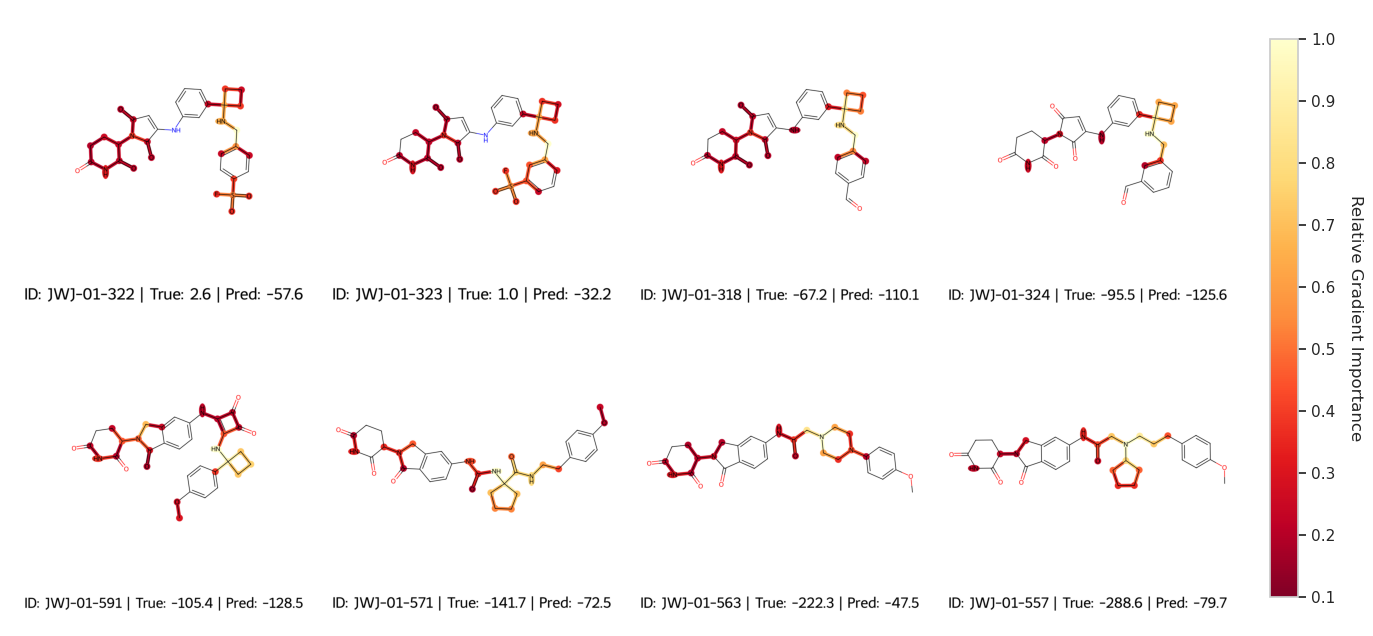


--- Generating Atom-Level Saliency Maps for Top 10 IKZF1-Selective MGDs ---


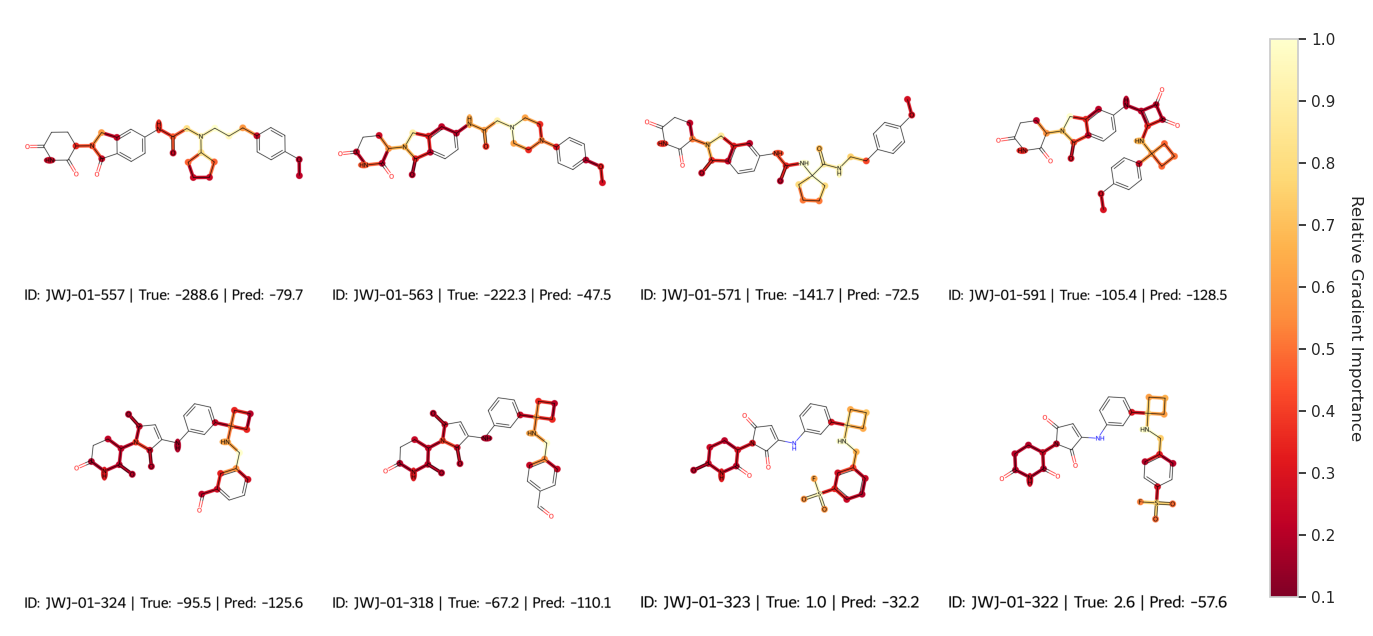

In [9]:
# 1. ATOM-LEVEL FEATURE ATTRIBUTION TO ZBTB11 SELECTIVITY (TOP 10 SALIENCY GRID)
print("\n--- Generating Atom-Level Saliency Maps for Top 10 ZBTB11-Selective MGDs ---")

top_10_df = test_results_df.sort_values(by='True_ZBTB11_Selectivity', ascending=False).head(10)

mols = []
highlight_atoms_list = []
highlight_colors_list = []
legends = []

final_model.eval()
final_model.cpu() 

colormap = plt.get_cmap('YlOrRd_r')

for idx, row in top_10_df.iterrows():
    smiles = row['SMILES']
    pred_score = row['Pred_ZBTB11_Selectivity']
    true_score = row['True_ZBTB11_Selectivity']
    compound_id = row['Molecule'] 
    
    extra_features = test_df[test_df['SMILES'] == smiles][extra_feature_cols].values[0]
    dp = data.MoleculeDatapoint.from_smi(smi=smiles, x_d=extra_features)
    dset = data.MoleculeDataset([dp], featurizer)
    loader = DataLoader(dset, batch_size=1, collate_fn=data.collate_batch)
    batch = next(iter(loader))
    
    batch.bmg.V.requires_grad_(True)
    
    preds, _ = final_model._get_predictions(batch)
    zbtb11_preds = preds[:, 0:10].sum()
    
    final_model.zero_grad()
    zbtb11_preds.backward()
    
    mol = Chem.MolFromSmiles(smiles)
    num_atoms = mol.GetNumAtoms()
    
    raw_gradients = batch.bmg.V.grad.abs().sum(dim=1).cpu().numpy()
    atom_importances = raw_gradients[:num_atoms]
    
    grad_min, grad_max = np.min(atom_importances), np.max(atom_importances)
    if grad_max > grad_min:
        importances_norm = (atom_importances - grad_min) / (grad_max - grad_min)
    else:
        importances_norm = np.zeros_like(atom_importances)
    
    atom_colors = {}
    hot_atoms = []
    
    for i in range(num_atoms):
        intensity = float(importances_norm[i])
        if intensity > 0.1:
            atom_colors[i] = tuple(colormap(intensity))
            hot_atoms.append(i)
            
    mols.append(mol)
    highlight_atoms_list.append(hot_atoms)
    highlight_colors_list.append(atom_colors)
    
    legends.append(f"ID: {compound_id} | True: {true_score:.1f} | Pred: {pred_score:.1f}")

draw_options = Draw.rdMolDraw2D.MolDrawOptions()
draw_options.legendFontSize = 60

grid_image = Draw.MolsToGridImage(
    mols, 
    molsPerRow=4, 
    subImgSize=(1000, 1000),
    highlightAtomLists=highlight_atoms_list, 
    highlightAtomColors=highlight_colors_list, 
    legends=legends,
    drawOptions=draw_options,
    returnPNG=False
)

fig, ax = plt.subplots(figsize=(18, 8)) 
ax.imshow(grid_image)
ax.axis('off')

norm = mpl.colors.Normalize(vmin=0.1, vmax=1.0)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap), 
                    ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Relative Gradient Importance', rotation=270, labelpad=20, fontsize=12)

plt.savefig("top_10_zbtb11_saliency_grid.png", dpi=1200, bbox_inches='tight')
plt.show()


# 2. ATOM-LEVEL FEATURE ATTRIBUTION TO IKZF1 SELECTIVITY (TOP 10 SALIENCY GRID)
print("\n--- Generating Atom-Level Saliency Maps for Top 10 IKZF1-Selective MGDs ---")

top_10_df = test_results_df.sort_values(by='True_ZBTB11_Selectivity', ascending=True).head(10)

mols = []
highlight_atoms_list = []
highlight_colors_list = []
legends = []

final_model.eval()
final_model.cpu() 

colormap = plt.get_cmap('YlOrRd_r')

for idx, row in top_10_df.iterrows():
    smiles = row['SMILES']
    pred_score = row['Pred_ZBTB11_Selectivity']
    true_score = row['True_ZBTB11_Selectivity']
    compound_id = row['Molecule'] 
    
    extra_features = test_df[test_df['SMILES'] == smiles][extra_feature_cols].values[0]
    dp = data.MoleculeDatapoint.from_smi(smi=smiles, x_d=extra_features)
    dset = data.MoleculeDataset([dp], featurizer)
    loader = DataLoader(dset, batch_size=1, collate_fn=data.collate_batch)
    batch = next(iter(loader))
    
    batch.bmg.V.requires_grad_(True)
    
    preds, _ = final_model._get_predictions(batch)
    ikzf1_preds = preds[:, 10:20].sum()
    
    final_model.zero_grad()
    ikzf1_preds.backward()
    
    mol = Chem.MolFromSmiles(smiles)
    num_atoms = mol.GetNumAtoms()
    
    raw_gradients = batch.bmg.V.grad.abs().sum(dim=1).cpu().numpy()
    atom_importances = raw_gradients[:num_atoms]
    
    grad_min, grad_max = np.min(atom_importances), np.max(atom_importances)
    if grad_max > grad_min:
        importances_norm = (atom_importances - grad_min) / (grad_max - grad_min)
    else:
        importances_norm = np.zeros_like(atom_importances)
    
    atom_colors = {}
    hot_atoms = []
    
    for i in range(num_atoms):
        intensity = float(importances_norm[i])
        if intensity > 0.1:
            atom_colors[i] = tuple(colormap(intensity))
            hot_atoms.append(i)
            
    mols.append(mol)
    highlight_atoms_list.append(hot_atoms)
    highlight_colors_list.append(atom_colors)
    
    legends.append(f"ID: {compound_id} | True: {true_score:.1f} | Pred: {pred_score:.1f}")

draw_options = Draw.rdMolDraw2D.MolDrawOptions()
draw_options.legendFontSize = 60

grid_image = Draw.MolsToGridImage(
    mols, 
    molsPerRow=4, 
    subImgSize=(1000, 1000),
    highlightAtomLists=highlight_atoms_list, 
    highlightAtomColors=highlight_colors_list, 
    legends=legends,
    drawOptions=draw_options,
    returnPNG=False
)

fig, ax = plt.subplots(figsize=(18, 8)) 
ax.imshow(grid_image)
ax.axis('off')

norm = mpl.colors.Normalize(vmin=0.1, vmax=1.0)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap), 
                    ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Relative Gradient Importance', rotation=270, labelpad=20, fontsize=12)

plt.savefig("top_10_ikzf1_saliency_grid.png", dpi=1200, bbox_inches='tight')
plt.show()